# Modelos de marea — Delta del Ebro (Mediterráneo)

## 🌊 Objetivos del análisis

1. **Obtener fechas válidas** de Sentinel-2 usando el pipeline SCL completo
2. **Calcular alturas de marea** con modelos globales (GOT4.10, CMEMS)
3. **Comparar con Foz (Atlántico)**: ¿El sesgo de observaciones varía geográficamente?
4. **Hipótesis**: ¿El sesgo hacia mareas bajas/altas depende de la región?

---

## 📍 Área de estudio

**Delta del Ebro** (Tarragona, costa mediterránea española):
- Latitud: 40.72°N
- Longitud: 0.73°E  
- Rango mareal: ~0.2-0.3 m (micromareales vs ~4m en Foz)
- Características: Delta con extensas zonas de humedales, arrozales y playas

---

## 🔄 Pipeline completo

Este notebook ejecuta **el mismo pipeline** que `foz_sentinel2_scl.ipynb`:

1. ✅ Consulta de sobrevuelos Sentinel-2 (STAC)
2. ✅ Descarga de mapas SCL
3. ✅ Construcción de reference map (píxeles estables agua/tierra)
4. ✅ Filtro de zona de transición (recupera fechas con nubes fuera del estuario)
5. ✅ Lista final de fechas válidas (sin nubes en zona intermareal)
6. ✅ Cálculo de alturas de marea en fechas válidas
7. ✅ Métricas de calidad (cobertura, VSR, uniformidad, sesgo)
8. ✅ Comparación regional (Mediterráneo vs Atlántico)

In [1]:
import sys
sys.path.insert(0, r"C:\Users\Jorge\sketch_fitton\Intertidal_analysis")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import time
import openeo
from datetime import datetime
from pathlib import Path
from shapely.geometry import box

from intertidal.tidemodel import PyTMDTideModel, CopernicusTideModel
from intertidal.overpass import get_overpass_times
from intertidal.tide_metrics import (
    calcular_metricas_completas,
    evaluar_calidad_distribucion,
    imprimir_metricas_completas
)
from intertidal import (
    download_date_scl,
    download_reference_map_openeo,
    evaluate_transition_cloud_coverage_openeo
)

print("✓ Módulos importados correctamente")

✓ Módulos importados correctamente


c:\Users\Jorge\sketch_fitton\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 · Configuración del AOI - Delta del Ebro

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN DEL ÁREA DE INTERÉS
# ══════════════════════════════════════════════════════════════════════════════

# Coordenadas del Delta del Ebro (costa mediterránea)
LAT_EBRO, LON_EBRO = 38.166, -0.476  # Centro aproximado del delta

# Bounding box que captura el delta y la zona intermareal
bbox_ebro = {
    "west":  -0.492,
    "south": 38.150,
    "east":  -0.458,
    "north": 38.175
}

# Periodo de análisis: 2015-2024 (mismo que Foz para comparabilidad)
time_extent_ebro = ["2016-01-01", "2025-01-01"]  # Se puede ampliar hasta 2024 si se desea

# Crear polígono del AOI
polygon_ebro = box(
    bbox_ebro['west'], bbox_ebro['south'],
    bbox_ebro['east'], bbox_ebro['north']
)

print("═" * 70)
print("CONFIGURACIÓN DEL ÁREA DE ESTUDIO")
print("═" * 70)
print(f"Sitio: Delta del Ebro (Tarragona, Mediterráneo)")
print(f"Coordenadas: {LAT_EBRO:.3f}°N, {LON_EBRO:.3f}°E")
print(f"Bounding box:")
print(f"  Oeste: {bbox_ebro['west']:.2f}°E")
print(f"  Este:  {bbox_ebro['east']:.2f}°E")
print(f"  Sur:   {bbox_ebro['south']:.2f}°N")
print(f"  Norte: {bbox_ebro['north']:.2f}°N")
print(f"Periodo: {time_extent_ebro[0]} → {time_extent_ebro[1]}")
print("═" * 70)

══════════════════════════════════════════════════════════════════════
CONFIGURACIÓN DEL ÁREA DE ESTUDIO
══════════════════════════════════════════════════════════════════════
Sitio: Delta del Ebro (Tarragona, Mediterráneo)
Coordenadas: 38.166°N, -0.476°E
Bounding box:
  Oeste: -0.49°E
  Este:  -0.46°E
  Sur:   38.15°N
  Norte: 38.17°N
Periodo: 2016-01-01 → 2025-01-01
══════════════════════════════════════════════════════════════════════


## 2 · Consultar sobrevuelos Sentinel-2 disponibles

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# PASO 1: Obtener fechas de sobrevuelo de Sentinel-2
# ══════════════════════════════════════════════════════════════════════════════

print("🛰️  Consultando catálogo STAC de Copernicus Dataspace...")
print(f"   Periodo: {time_extent_ebro[0]} → {time_extent_ebro[1]}")
print(f"   Región: Delta del Ebro\n")

t0 = time.time()
overpass_dict_ebro = get_overpass_times(bbox_ebro, time_extent_ebro)
elapsed = time.time() - t0
print(overpass_dict_ebro)
if not overpass_dict_ebro:
    raise RuntimeError(
        "❌ No se obtuvieron fechas del catálogo STAC.\n"
        "   Revisa la conexión, el bbox o el periodo temporal."
    )

# Convertir a DataFrame para análisis
overpass_df_ebro = pd.DataFrame(
    [(date_str, dt) for date_str, dt in overpass_dict_ebro.items()],
    columns=["date_str", "datetime"]
).sort_values("datetime").reset_index(drop=True)

# Estadísticas por año
overpass_df_ebro['year'] = overpass_df_ebro['datetime'].dt.year
yearly_counts = overpass_df_ebro.groupby('year').size()

print("\n" + "═" * 70)
print(f"✅ SOBREVUELOS OBTENIDOS: {len(overpass_df_ebro)} fechas en {elapsed:.1f}s")
print("═" * 70)
print("\nDistribución por año:")
for year, count in yearly_counts.items():
    print(f"  {year}: {count:3d} sobrevuelos")

print(f"\nTotal: {len(overpass_df_ebro)} sobrevuelos disponibles")

🛰️  Consultando catálogo STAC de Copernicus Dataspace...
   Periodo: 2016-01-01 → 2025-01-01
   Región: Delta del Ebro

{'2016-01-02': datetime.datetime(2016, 1, 2, 10, 54, 42), '2016-01-12': datetime.datetime(2016, 1, 12, 10, 54, 22), '2016-01-22': datetime.datetime(2016, 1, 22, 10, 53, 42), '2016-02-01': datetime.datetime(2016, 2, 1, 10, 52, 52), '2016-02-11': datetime.datetime(2016, 2, 11, 10, 51, 52), '2016-02-21': datetime.datetime(2016, 2, 21, 10, 50, 52), '2016-03-02': datetime.datetime(2016, 3, 2, 10, 50, 42), '2016-03-12': datetime.datetime(2016, 3, 12, 10, 50, 42), '2016-03-22': datetime.datetime(2016, 3, 22, 10, 50, 42), '2016-04-01': datetime.datetime(2016, 4, 1, 10, 50, 22), '2016-04-11': datetime.datetime(2016, 4, 11, 10, 50, 22), '2016-04-21': datetime.datetime(2016, 4, 21, 10, 50, 32), '2016-05-01': datetime.datetime(2016, 5, 1, 10, 50, 32), '2016-05-11': datetime.datetime(2016, 5, 11, 10, 50, 32), '2016-05-21': datetime.datetime(2016, 5, 21, 10, 50, 32), '2016-06-10': 

## 3 · Conectar con OpenEO y configurar directorios

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# PASO 2: Conectar con OpenEO (Copernicus Dataspace)
# ══════════════════════════════════════════════════════════════════════════════

print("🔗 Conectando con Copernicus Dataspace (OpenEO)...")
conn = openeo.connect("openeo.dataspace.copernicus.eu")
conn.authenticate_oidc()
print("✓ Conexión autenticada\n")

# Crear directorios para datos
dir_scl_ebro = "./tifs_scl_ebro"
dir_rgb_ebro = "./tifs_rgb_ebro"

Path(dir_scl_ebro).mkdir(exist_ok=True)
Path(dir_rgb_ebro).mkdir(exist_ok=True)

print(f"📁 Directorios configurados:")
print(f"   SCL: {dir_scl_ebro}")
print(f"   RGB: {dir_rgb_ebro}")

🔗 Conectando con Copernicus Dataspace (OpenEO)...
Authenticated using refresh token.
✓ Conexión autenticada

📁 Directorios configurados:
   SCL: ./tifs_scl_ebro
   RGB: ./tifs_rgb_ebro


## 5 · Configurar parámetros del pipeline

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# PASO 4: Configuración de parámetros del pipeline
# ══════════════════════════════════════════════════════════════════════════════

# Clases SCL consideradas "malas" (nubes, sombras, nieve, sin datos)
ref_bad_classes = [0, 1, 2, 3, 7, 8, 9, 10, 11]

# Umbrales de filtrado
ref_bad_fraction_threshold = 0.05  # 5% máximo de píxeles malos para reference map
ref_stable_threshold = 0.90  # 90% de consistencia para píxeles estables
transition_cloud_threshold = 0.20  # 20% máximo en zona de transición

print("Configuración del pipeline:")
print(f"  Clases malas SCL: {ref_bad_classes}")
print(f"  Umbral reference map: {ref_bad_fraction_threshold*100:.0f}%")
print(f"  Umbral estabilidad: {ref_stable_threshold*100:.0f}%")
print(f"  Umbral zona transición: {transition_cloud_threshold*100:.0f}%")

Configuración del pipeline:
  Clases malas SCL: [0, 1, 2, 3, 7, 8, 9, 10, 11]
  Umbral reference map: 5%
  Umbral estabilidad: 90%
  Umbral zona transición: 20%


## 6 · Construir Reference Map

El reference map identifica píxeles estables (siempre agua o siempre tierra) usando votación mayoritaria de fechas limpias.

🗺️  Generando reference map con OpenEO...
   Periodo: 2016-01-01 → 2025-01-01
   Umbral calidad: ≤5% píxeles malos
   Umbral estabilidad: ≥90% consistencia
   Esto puede tardar 10-15 minutos...

    Reference map ya existe en ./reference_map_ebro.tif, saltando.
Dimensiones: (2831, 2185)  (43700×56620 m a 20m/px)
CRS:         EPSG:32631

  0  Transición   ← zona intermareal candidata      2,507,698 px (40.5%)
  1  Agua estable ← nunca al descubierto            2,491,930 px (40.3%)
  2  Tierra estable ← nunca inundada                1,186,107 px (19.2%)

→ La zona de transición tiene 2,507,698 píxeles
  (1003.08 km² a 20m/px)


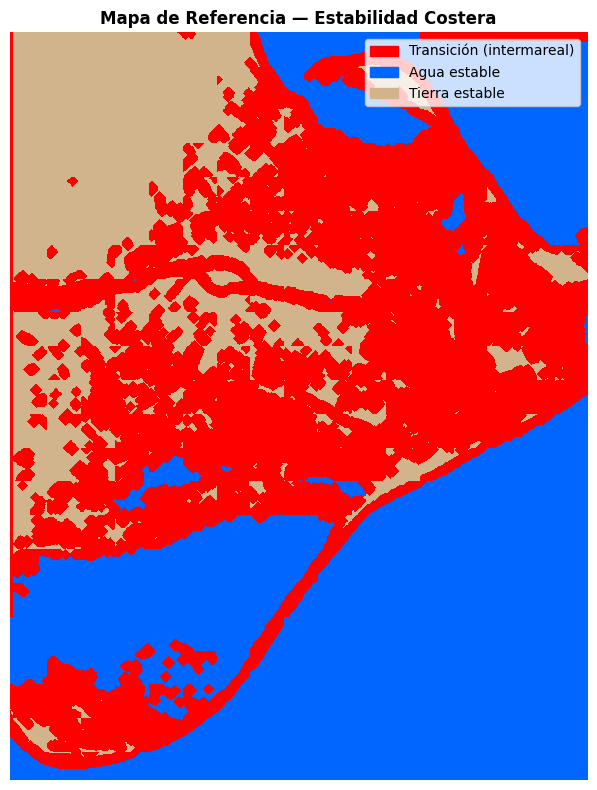

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# PASO 5: Generar Reference Map usando OpenEO
# ══════════════════════════════════════════════════════════════════════════════
from intertidal.notebook_compat import (
    load_reference_map_tif,
    plot_reference_map,
)



ref_map_path_ebro = "./reference_map_ebro.tif"

print("🗺️  Generando reference map con OpenEO...")
print(f"   Periodo: {time_extent_ebro[0]} → {time_extent_ebro[1]}")
print(f"   Umbral calidad: ≤{ref_bad_fraction_threshold*100:.0f}% píxeles malos")
print(f"   Umbral estabilidad: ≥{ref_stable_threshold*100:.0f}% consistencia")
print(f"   Esto puede tardar 10-15 minutos...\n")

status_ref = download_reference_map_openeo(
    conn=conn,
    bbox=bbox_ebro,
    time_extent=time_extent_ebro,
    out_path=ref_map_path_ebro,
    bad_classes=ref_bad_classes,
    bad_fraction_threshold=ref_bad_fraction_threshold,
    stable_threshold=ref_stable_threshold,
    transition_buffer_pixels=20,
    force=False,  # ← cambiar a False si el fichero ya existe y no quieres recalcular
    )

# ── Cargar el Reference Map descargado y visualizarlo ─────────────────────────
# Lee el GeoTIFF del reference map desde disco y extrae:
#   - reference_map_openeo : array 2D uint8 con valores 0/1/2
#   - ref_transform        : transformada afín (mapea píxeles a coordenadas)
#   - ref_crs              : sistema de referencia (normalmente UTM zona 29N)

reference_map_openeo, ref_transform, ref_crs = load_reference_map_tif(ref_map_path_ebro)

# La transition_mask es simplemente todos los píxeles con valor 0
# (aquellos que NO son ni agua estable ni tierra estable)
transition_mask = (reference_map_openeo == 0)

# ── Estadísticas del reference map ────────────────────────────────────────────
print(f"Dimensiones: {reference_map_openeo.shape}  ({reference_map_openeo.shape[1]*20}×{reference_map_openeo.shape[0]*20} m a 20m/px)")
print(f"CRS:         {ref_crs}")
print()

# Contar y mostrar la distribución de píxeles por clase
for val, label in [
    (0, "Transición   ← zona intermareal candidata"),
    (1, "Agua estable ← nunca al descubierto"),
    (2, "Tierra estable ← nunca inundada"),
]:
    n = (reference_map_openeo == val).sum()
    pct = 100 * n / reference_map_openeo.size
    print(f"  {val}  {label:<45}  {n:>8,} px ({pct:.1f}%)")

print(f"\n→ La zona de transición tiene {transition_mask.sum():,} píxeles")
print(f"  ({transition_mask.sum() * 400 / 1e6:.2f} km² a 20m/px)")

# Visualizar con colores: rojo=transición, azul=agua, arena=tierra
plot_reference_map(reference_map_openeo)

## 7 · Filtro de zona de transición

Evaluamos la nubosidad en la zona de transición (intermareal) para cada fecha. Esto permite recuperar fechas que tienen nubes fuera del estuario pero están limpias en la zona de interés.

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# PASO 6: Evaluar nubosidad en zona de transición
# ══════════════════════════════════════════════════════════════════════════════

print("☁️  Evaluando nubosidad en zona de transición...")
print(f"   Esto identifica fechas limpias en el estuario")
print(f"   Puede tardar 10-15 minutos...\n")

transition_stats_raw_ebro = evaluate_transition_cloud_coverage_openeo(
    conn=conn,
    bbox=bbox_ebro,
    time_extent=time_extent_ebro,
    reference_map=reference_map_openeo,
    reference_transform=ref_transform,
    bad_classes=ref_bad_classes,
    reference_dates=[],
    global_bad_fraction_threshold=ref_bad_fraction_threshold,
    scl_dir=dir_scl_ebro
)

# Convertir al formato estándar
transition_stats_ebro = {
    date: {
        "bad_fraction": pct / 100,
        "bad_pct": pct,
    }
    for date, pct in transition_stats_raw_ebro.items()
}

# Clasificar fechas
n_ref_quality = sum(1 for s in transition_stats_ebro.values() 
                   if s["bad_fraction"] <= ref_bad_fraction_threshold)
n_transition_only = sum(1 for s in transition_stats_ebro.values() 
                       if s["bad_fraction"] > ref_bad_fraction_threshold 
                       and s["bad_fraction"] <= transition_cloud_threshold)
n_discarded = sum(1 for s in transition_stats_ebro.values() 
                 if s["bad_fraction"] > transition_cloud_threshold)

print(f"\n{'='*70}")
print(f"RESULTADOS DEL FILTRO DE TRANSICIÓN")
print(f"{'='*70}")
print(f"  Total evaluadas: {len(transition_stats_ebro)}")
print(f"  Calidad referencia (≤{ref_bad_fraction_threshold*100:.0f}%): {n_ref_quality}")
print(f"  Válidas en transición: {n_transition_only}")
print(f"  Descartadas (>{transition_cloud_threshold*100:.0f}%): {n_discarded}")
print(f"  TOTAL VÁLIDAS: {n_ref_quality + n_transition_only}")

☁️  Evaluando nubosidad en zona de transición...
   Esto identifica fechas limpias en el estuario
   Puede tardar 10-15 minutos...

  Consultando fechas (2020-01-01 -> 2025-01-01)...
  Ejemplo fechas parseadas: ['2020-01-01', '2020-01-06', '2020-01-11']
  Fechas totales: 364 | Referencia: 0 | A evaluar: 364
  Lanzando batch job (descarga del cubo SCL completo)...
0:00:00 Job 'j-2607270914244b4f9e8df8a5f4c2ef9f': send 'start'
0:00:02 Job 'j-2607270914244b4f9e8df8a5f4c2ef9f': queued (progress 0%)
0:00:07 Job 'j-2607270914244b4f9e8df8a5f4c2ef9f': queued (progress 0%)
0:00:13 Job 'j-2607270914244b4f9e8df8a5f4c2ef9f': queued (progress 0%)
0:00:22 Job 'j-2607270914244b4f9e8df8a5f4c2ef9f': queued (progress 0%)
0:00:31 Job 'j-2607270914244b4f9e8df8a5f4c2ef9f': queued (progress 0%)
0:00:44 Job 'j-2607270914244b4f9e8df8a5f4c2ef9f': queued (progress 0%)
0:00:59 Job 'j-2607270914244b4f9e8df8a5f4c2ef9f': running (progress N/A)
0:01:18 Job 'j-2607270914244b4f9e8df8a5f4c2ef9f': running (progress N/A)

## 8 · Obtener lista final de fechas válidas

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# PASO 7: Obtener lista final de fechas válidas
# ══════════════════════════════════════════════════════════════════════════════

# Filtrar fechas válidas (≤ 20% nubes en zona de transición)
valid_dates_ebro = [
    date for date, stats in transition_stats_ebro.items()
    if stats["bad_fraction"] <= transition_cloud_threshold
]

# Ordenar cronológicamente
valid_dates_ebro = sorted(valid_dates_ebro)

# Filtrar DataFrame de sobrevuelos
selected_overpass_df_ebro = overpass_df_ebro[
    overpass_df_ebro['date_str'].isin(valid_dates_ebro)
].copy().reset_index(drop=True)

# Extraer lista de fechas
selected_dates_ebro = selected_overpass_df_ebro['date_str'].tolist()

# Estadísticas por año
selected_overpass_df_ebro['year'] = selected_overpass_df_ebro['datetime'].dt.year
selected_yearly = selected_overpass_df_ebro.groupby('year').size()

print(f"\n{'='*70}")
print(f"✅ FECHAS VÁLIDAS FINALES: {len(selected_dates_ebro)}")
print(f"{'='*70}")
print(f"\nDistribución por año:")
for year, count in selected_yearly.items():
    print(f"  {year}: {count:3d} fechas válidas")

tasa_exito = 100 * len(selected_dates_ebro) / len(overpass_df_ebro)
print(f"\nTasa de éxito global: {tasa_exito:.1f}%")
if n_ref_quality + n_transition_only > 0:
    tasa_recuperacion = 100 * n_transition_only / (n_ref_quality + n_transition_only)
    print(f"Tasa de recuperación (transición): {tasa_recuperacion:.1f}%")

print(f"\n💾 Guardando lista de fechas válidas...")
with open("valid_dates_ebro.txt", "w") as f:
    f.write("\n".join(selected_dates_ebro))
print(f"   Guardado en: valid_dates_ebro.txt")


✅ FECHAS VÁLIDAS FINALES: 219

Distribución por año:
  2020:  39 fechas válidas
  2021:  46 fechas válidas
  2022:  41 fechas válidas
  2023:  43 fechas válidas
  2024:  50 fechas válidas

Tasa de éxito global: 60.2%
Tasa de recuperación (transición): 5.5%

💾 Guardando lista de fechas válidas...
   Guardado en: valid_dates_ebro.txt


## 9 · Configurar modelos de marea

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# PASO 8: Configurar modelos de marea
# ══════════════════════════════════════════════════════════════════════════════

tide_models_ebro = {}

# Modelo 1: GOT4.10 (PyTMD)
print("\n" + "═" * 70)
print("Configurando modelo PyTMD: GOT4.10")
print("═" * 70)
try:
    tide_models_ebro["GOT4.10"] = PyTMDTideModel(
        model_name="GOT4.10",
        directory="./tide_models",
        box_size=2.0,
        resolution=0.1
    )
    print("✓ GOT4.10 configurado correctamente")
except Exception as e:
    print(f"✗ Error configurando GOT4.10: {e}")

# Modelo 2: CMEMS (Copernicus Marine)
print("\n" + "═" * 70)
print("Configurando modelo CMEMS (Copernicus Marine)")
print("═" * 70)
try:
    tide_models_ebro["CMEMS"] = CopernicusTideModel()
    print("✓ CMEMS configurado correctamente")
except Exception as e:
    print(f"✗ Error configurando CMEMS: {e}")

print("\n" + "═" * 70)
print(f"RESUMEN: {len(tide_models_ebro)} modelos configurados")
print("═" * 70)
for model_name in tide_models_ebro.keys():
    print(f"  • {model_name}")


══════════════════════════════════════════════════════════════════════
Configurando modelo PyTMD: GOT4.10
══════════════════════════════════════════════════════════════════════
Modelo GOT4.10 ya descargado
✓ GOT4.10 configurado correctamente

══════════════════════════════════════════════════════════════════════
Configurando modelo CMEMS (Copernicus Marine)
══════════════════════════════════════════════════════════════════════


INFO - 2026-07-27T09:21:39Z - Using existing credentials from C:\Users\Jorge\.copernicusmarine\.copernicusmarine-credentials. Use --force-overwrite combined with credentials (specified by arguments, netrc file or environment variables) to always overwrite.
INFO:copernicusmarine:Using existing credentials from C:\Users\Jorge\.copernicusmarine\.copernicusmarine-credentials. Use --force-overwrite combined with credentials (specified by arguments, netrc file or environment variables) to always overwrite.


✓ CMEMS configurado correctamente

══════════════════════════════════════════════════════════════════════
RESUMEN: 2 modelos configurados
══════════════════════════════════════════════════════════════════════
  • GOT4.10
  • CMEMS


## 10 · Calcular alturas de marea

### 10.1 Distribución de referencia (cada 2 horas)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PASO 9A: Calcular distribución de REFERENCIA (muestreo cada 2h)
# ══════════════════════════════════════════════════════════════════════════════

print("\n🌊 Calculando distribución de marea de REFERENCIA (cada 2 horas)...")
print("   Periodo: 2016-01-01 → 2024-06-30")
print("   Esto representa la distribución 'completa' teórica\n")

# Muestreo denso (cada 2h) para capturar bien las oscilaciones
dates_reference = pd.date_range("2016-01-01", "2024-06-30 23:00", freq="2h")
print(f"  {len(dates_reference)} mediciones (cada 2h)\n")

# Calcular alturas para cada modelo
mareas_referencia_ebro = {}

for model_name, model in tide_models_ebro.items():
    print(f"  • {model_name}...", end=" ")
    t0 = time.time()
    heights = model.get_tide_heights_batch(
        LAT_EBRO, LON_EBRO, 
        [d.to_pydatetime() for d in dates_reference]
    )
    mareas_referencia_ebro[model_name] = heights
    rango = max(heights) - min(heights)
    print(f"{len(heights)} valores en {time.time()-t0:.1f}s (rango: {rango:.3f} m)")

print(f"\n✓ Mareas de referencia calculadas para {len(tide_models_ebro)} modelos")
print("\nEstadísticas de la distribución de referencia:")
for model_name, heights in mareas_referencia_ebro.items():
    h_arr = np.array(heights)
    print(f"  {model_name:12s} → min: {h_arr.min():+.3f} m, "
          f"max: {h_arr.max():+.3f} m, "
          f"rango: {h_arr.max()-h_arr.min():.3f} m, "
          f"std: {h_arr.std():.3f} m")


🌊 Calculando distribución de marea de REFERENCIA (cada 2 horas)...
   Periodo: 2024-01-01 → 2024-06-30
   Esto representa la distribución 'completa' teórica

  2184 mediciones (cada 2h)

  • GOT4.10... 2184 valores en 5.1s (rango: 0.252 m)
  • CMEMS... 

INFO - 2026-07-27T09:21:50Z - Selected dataset version: "202511"
INFO:copernicusmarine:Selected dataset version: "202511"
INFO - 2026-07-27T09:21:50Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"


2184 valores en 6.2s (rango: 0.556 m)

✓ Mareas de referencia calculadas para 2 modelos

Estadísticas de la distribución de referencia:
  GOT4.10      → min: -0.151 m, max: +0.101 m, rango: 0.252 m, std: 0.049 m
  CMEMS        → min: -0.798 m, max: -0.242 m, rango: 0.556 m, std: 0.090 m


### 10.2 Alturas de marea en fechas seleccionadas

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# PASO 9B: Calcular mareas en FECHAS VÁLIDAS (fechas del pipeline completo)
# ══════════════════════════════════════════════════════════════════════════════

print("\n🌊 Calculando alturas de marea en FECHAS VÁLIDAS...")
print(f"   {len(selected_dates_ebro)} fechas del pipeline SCL completo\n")

# Calcular alturas para cada modelo
mareas_seleccionadas_ebro = {}

for model_name, model in tide_models_ebro.items():
    print(f"  • {model_name}...", end=" ")
    t0 = time.time()
    heights = model.get_tide_heights_batch(
        LAT_EBRO, LON_EBRO,
        selected_overpass_df_ebro["datetime"].tolist()
    )
    mareas_seleccionadas_ebro[model_name] = heights
    rango = max(heights) - min(heights)
    print(f"{len(heights)} valores en {time.time()-t0:.1f}s (rango: {rango:.3f} m)")

# Añadir columnas al DataFrame
for model_name, heights in mareas_seleccionadas_ebro.items():
    selected_overpass_df_ebro[model_name] = heights

print(f"\n✓ Mareas calculadas para {len(tide_models_ebro)} modelos")
print("\nEstadísticas de las fechas seleccionadas:")
for model_name, heights in mareas_seleccionadas_ebro.items():
    h_arr = np.array(heights)
    print(f"  {model_name:12s} → min: {h_arr.min():+.3f} m, "
          f"max: {h_arr.max():+.3f} m, "
          f"rango: {h_arr.max()-h_arr.min():.3f} m, "
          f"std: {h_arr.std():.3f} m")


🌊 Calculando alturas de marea en FECHAS VÁLIDAS...
   219 fechas del pipeline SCL completo

  • GOT4.10... 219 valores en 6.4s (rango: 0.212 m)
  • CMEMS... 

INFO - 2026-07-27T09:22:06Z - Selected dataset version: "202511"
INFO:copernicusmarine:Selected dataset version: "202511"
INFO - 2026-07-27T09:22:06Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"


219 valores en 6.0s (rango: 0.462 m)

✓ Mareas calculadas para 2 modelos

Estadísticas de las fechas seleccionadas:
  GOT4.10      → min: -0.128 m, max: +0.084 m, rango: 0.212 m, std: 0.055 m
  CMEMS        → min: -0.728 m, max: -0.265 m, rango: 0.462 m, std: 0.091 m


## 11 · Análisis de métricas de calidad

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# PASO 10: Calcular métricas de calidad para cada modelo
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 70)
print("ANÁLISIS DE CALIDAD DE DISTRIBUCIONES MAREALES")
print("═" * 70)
print("Método waterline: evaluación de aptitud para reconstrucción batimétrica\n")

metricas_por_modelo_ebro = {}

for model_name in tide_models_ebro.keys():
    print("\n" + "─" * 70)
    print(f"Modelo: {model_name}")
    print("─" * 70)
    
    # Valores observados (fechas seleccionadas) vs referencia (cada 2h)
    valores_observados = np.array(mareas_seleccionadas_ebro[model_name])
    valores_referencia = np.array(mareas_referencia_ebro[model_name])
    
    # Calcular métricas completas
    metricas = calcular_metricas_completas(valores_observados, valores_referencia)
    metricas_por_modelo_ebro[model_name] = metricas
    
    # Imprimir métricas formateadas
    imprimir_metricas_completas(metricas)
    
    # Evaluación cualitativa
    print("\n" + "─" * 70)
    print("Evaluación de calidad:")
    print("─" * 70)
    evaluacion = evaluar_calidad_distribucion(valores_observados, valores_referencia)
    print(evaluacion)

print("\n" + "═" * 70)
print("✓ Análisis de métricas completado")
print("═" * 70)


══════════════════════════════════════════════════════════════════════
ANÁLISIS DE CALIDAD DE DISTRIBUCIONES MAREALES
══════════════════════════════════════════════════════════════════════
Método waterline: evaluación de aptitud para reconstrucción batimétrica


──────────────────────────────────────────────────────────────────────
Modelo: GOT4.10
──────────────────────────────────────────────────────────────────────

📏 COBERTURA DEL RANGO MAREAL:
  • Rango válido:     0.21 m  [-0.13 → 0.08]
  • Rango total:      0.25 m  [-0.15 → 0.10]
  • Cobertura:        0.840 (84.0%)

📐 TEST DE UNIFORMIDAD (Kolmogorov-Smirnov):
  • Estadístico KS:   0.1484
  • P-value:          0.0001
  • ¿Uniforme?        No (Altamente no uniforme)

🔢 ENTROPÍA DE SHANNON:
  • Entropía:         3.946 bits
  • Entropía máx:     4.322 bits
  • Normalizada:      0.913 (0-1, mayor = más uniforme)
  • Bins ocupados:    18/20 (2 vacíos)

📊 ÍNDICE DE DISPERSIÓN (VMR):
  • VMR:              0.001
  • Patrón:           Reg

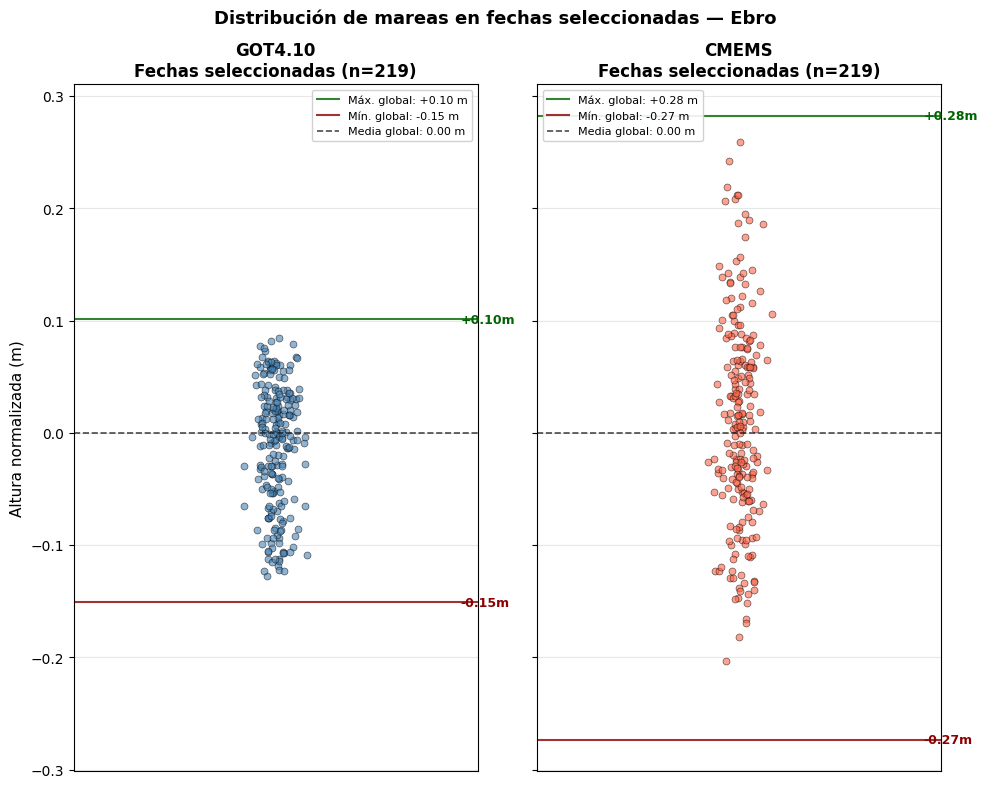

In [13]:
# ────────────────────────────────────────────────────────────────────
# VISUALIZACIÓN: Distribución vertical de mareas en fechas seleccionadas
# ────────────────────────────────────────────────────────────────────

# Colores para cada modelo
model_colors = {
    "GOT4.10": "steelblue",
    "FES2014": "darkgreen",
    "FES2022": "purple",
    "CMEMS": "tomato",
}

# Crear subplot para cada modelo
n_models = len(tide_models_ebro)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 8), sharey=True)
if n_models == 1:
    axes = [axes]

for idx, (model_name, heights) in enumerate(mareas_seleccionadas_ebro.items()):
    ax = axes[idx]
    color = model_colors.get(model_name, "gray")
    
    # Normalizar restando la media de la distribución completa de referencia
    full_heights = mareas_referencia_ebro[model_name]
    full_mean = np.mean(full_heights)
    heights_norm = np.array(heights) - full_mean
    
    # Límites globales (de la distribución completa normalizada)
    full_norm = np.array(full_heights) - full_mean
    ref_min, ref_max = full_norm.min(), full_norm.max()
    margin = 0.05 * (ref_max - ref_min)
    ylim = (ref_min - margin, ref_max + margin)
    
    # Scatter vertical con jitter
    x_jitter = np.random.normal(0, 0.02, len(heights_norm))
    ax.scatter(x_jitter, heights_norm, alpha=0.6, s=25, color=color,
               edgecolor='black', linewidth=0.5)
    
    # Líneas de referencia (de la distribución completa)
    ax.axhline(ref_max, color='darkgreen', linewidth=1.5, linestyle='-', alpha=0.8, 
               label=f'Máx. global: {ref_max:+.2f} m')
    ax.axhline(ref_min, color='darkred', linewidth=1.5, linestyle='-', alpha=0.8, 
               label=f'Mín. global: {ref_min:+.2f} m')
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.7, 
               label='Media global: 0.00 m')
    
    # Anotaciones
    ax.text(0.32, ref_max, f'{ref_max:+.2f}m', fontsize=9, va='center', 
            color='darkgreen', fontweight='bold')
    ax.text(0.32, ref_min, f'{ref_min:+.2f}m', fontsize=9, va='center', 
            color='darkred', fontweight='bold')
    
    ax.set_xlim(-0.35, 0.35)
    ax.set_ylim(ylim)
    ax.set_xticks([])
    if idx == 0:
        ax.set_ylabel("Altura normalizada (m)", fontsize=11)
    ax.set_title(f"{model_name}\nFechas seleccionadas (n={len(heights)})", 
                 fontsize=12, fontweight="bold")
    ax.grid(alpha=0.3, axis='y')
    ax.legend(loc='best', fontsize=8, framealpha=0.9)

fig.suptitle('Distribución de mareas en fechas seleccionadas — Ebro', 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 13 · Serie temporal de mareas observadas

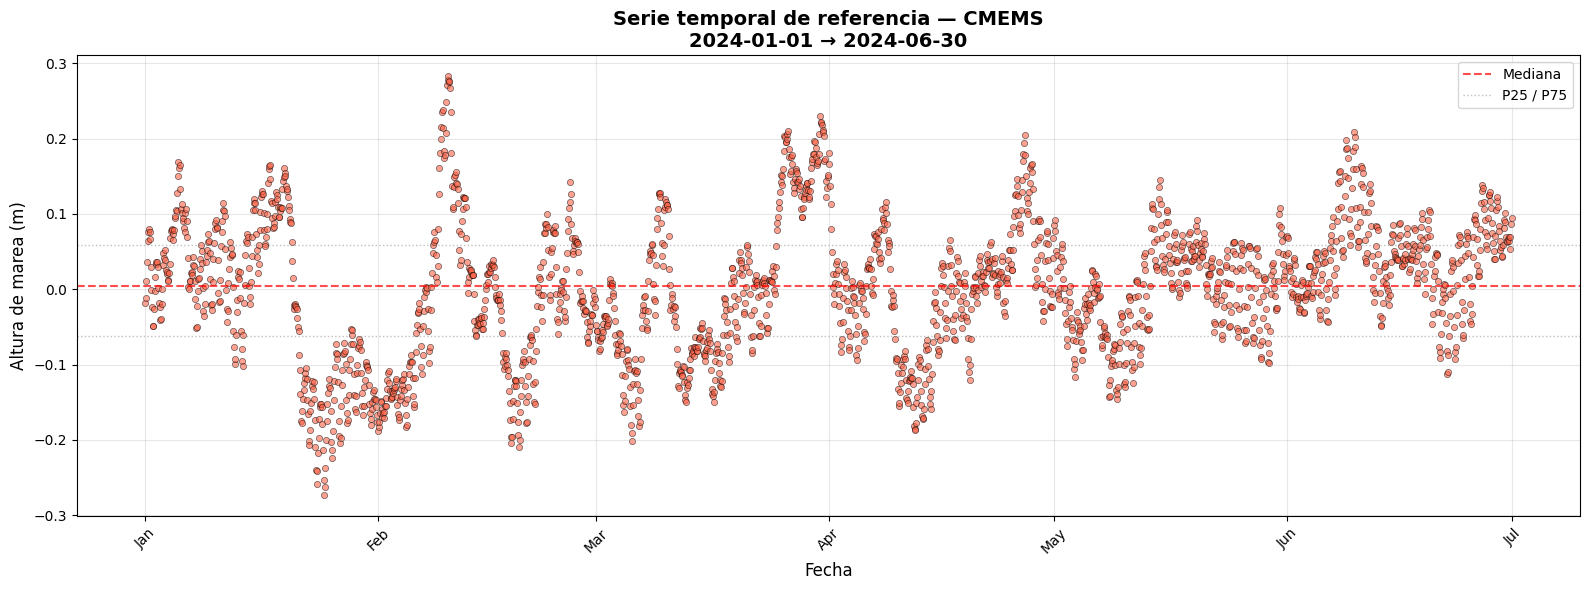

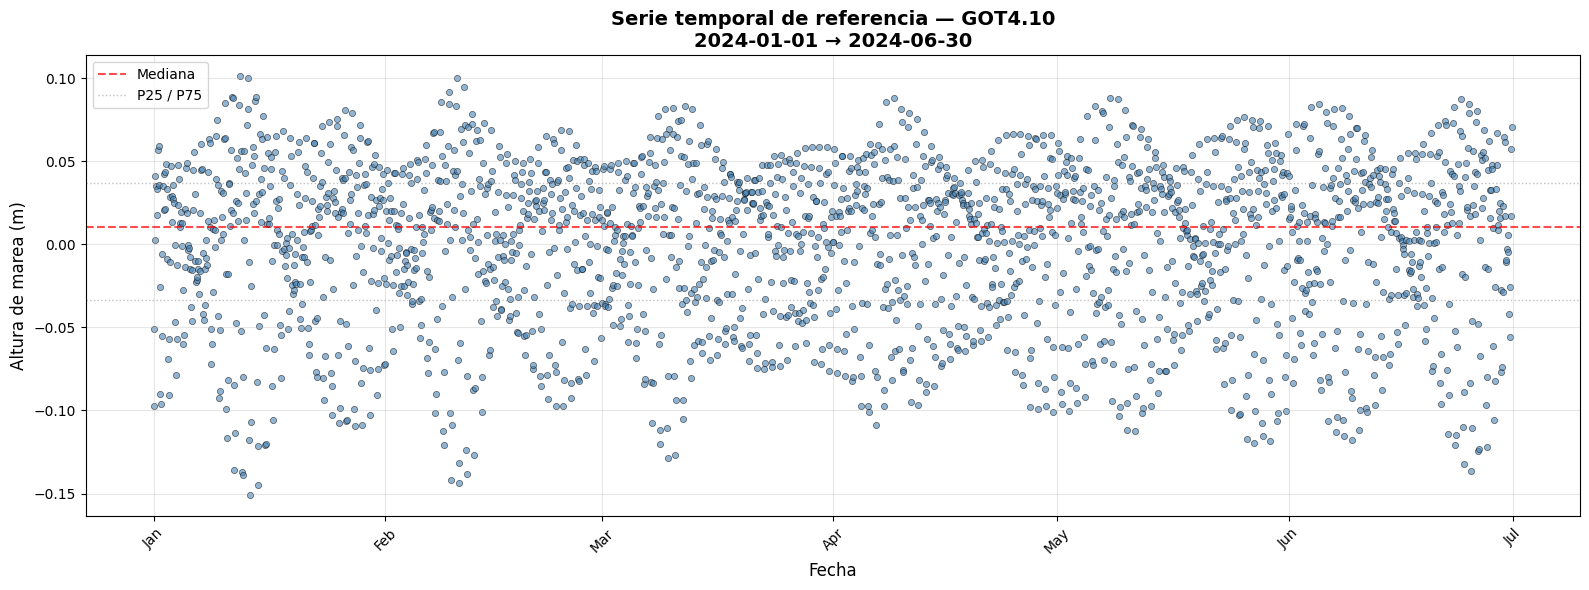

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN: Serie temporal de referencia (CMEMS)
# ══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(16, 6))

heights = np.array(mareas_referencia_ebro["CMEMS"]-np.mean(mareas_referencia_ebro["CMEMS"]))

ax.scatter(
    dates_reference,
    heights,
    color=model_colors.get("CMEMS", "tab:blue"),
    alpha=0.6,
    s=20,
    edgecolors="black",
    linewidth=0.5
)

# Percentiles
p25, p50, p75 = np.percentile(heights, [25, 50, 75])

ax.axhline(p50, color='red', linestyle='--', linewidth=1.5,
           alpha=0.7, label='Mediana')
ax.axhline(p25, color='gray', linestyle=':', linewidth=1,
           alpha=0.5, label='P25 / P75')
ax.axhline(p75, color='gray', linestyle=':', linewidth=1,
           alpha=0.5)

ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Altura de marea (m)", fontsize=12)
ax.set_title(
    "Serie temporal de referencia — CMEMS\n"
    "2024-01-01 → 2024-06-30",
    fontsize=14,
    fontweight="bold"
)

ax.grid(True, alpha=0.3)
ax.legend()

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
# ══════════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN: Serie temporal de referencia (GOT4.10)
# ══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(16, 6))

heights = np.array(mareas_referencia_ebro["GOT4.10"]-np.mean(mareas_referencia_ebro["GOT4.10"]))

ax.scatter(
    dates_reference,
    heights,
    color=model_colors.get("GOT4.10", "tab:orange"),
    alpha=0.6,
    s=20,
    edgecolors="black",
    linewidth=0.5
)

# Percentiles
p25, p50, p75 = np.percentile(heights, [25, 50, 75])

ax.axhline(p50, color='red', linestyle='--', linewidth=1.5,
           alpha=0.7, label='Mediana')
ax.axhline(p25, color='gray', linestyle=':', linewidth=1,
           alpha=0.5, label='P25 / P75')
ax.axhline(p75, color='gray', linestyle=':', linewidth=1,
           alpha=0.5)

ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Altura de marea (m)", fontsize=12)
ax.set_title(
    "Serie temporal de referencia — GOT4.10\n"
    "2024-01-01 → 2024-06-30",
    fontsize=14,
    fontweight="bold"
)

ax.grid(True, alpha=0.3)
ax.legend()

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

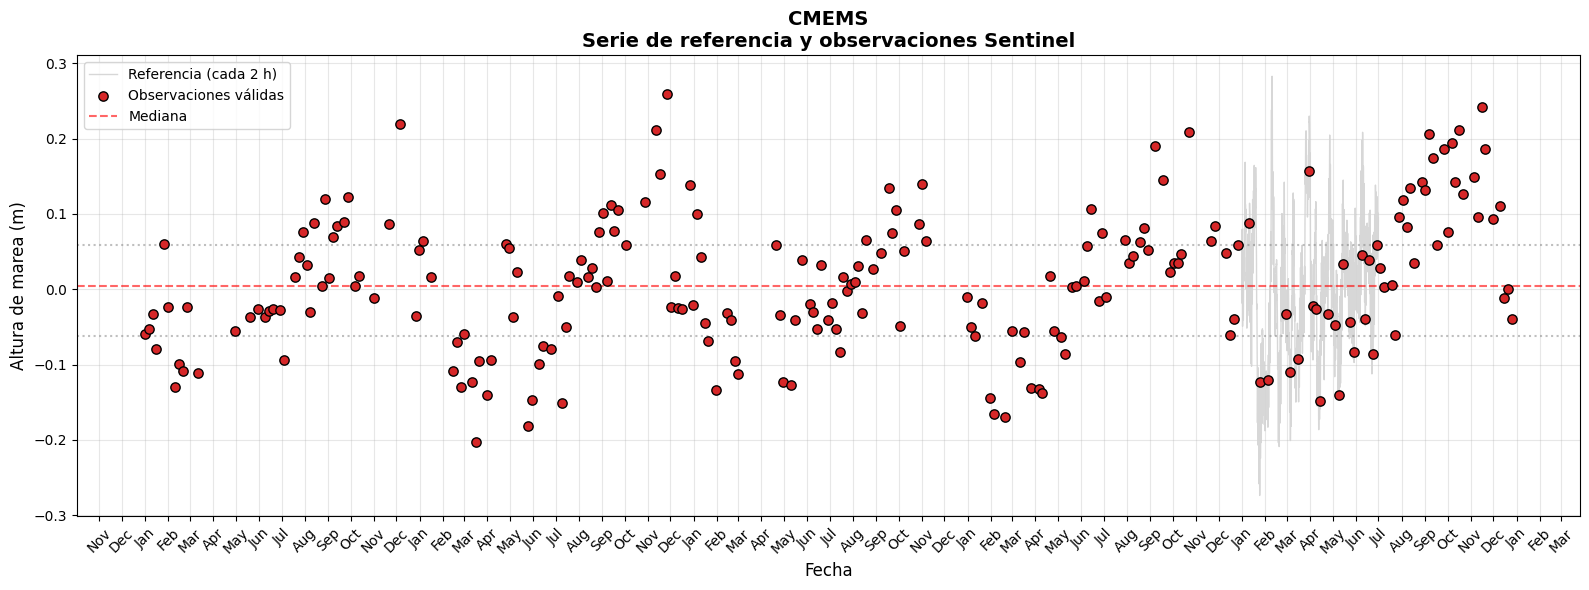

In [17]:
fig, ax = plt.subplots(figsize=(16, 6))

# ==========================
# Serie de referencia
# ==========================

ref = np.array(mareas_referencia_ebro["CMEMS"])
ref = ref - np.mean(ref)

ax.plot(
    dates_reference,
    ref,
    color="lightgray",
    linewidth=1.0,
    alpha=0.9,
    label="Referencia (cada 2 h)"
)

# ==========================
# Observaciones Sentinel
# ==========================

obs = np.array(mareas_seleccionadas_ebro["CMEMS"])
obs = obs - np.mean(mareas_referencia_ebro["CMEMS"])   # misma referencia

ax.scatter(
    selected_overpass_df_ebro["datetime"],
    obs,
    color="tab:red",
    edgecolors="black",
    s=45,
    zorder=5,
    label="Observaciones válidas"
)

# ==========================
# Percentiles de referencia
# ==========================

p25, p50, p75 = np.percentile(ref, [25, 50, 75])

ax.axhline(p50, color='red', linestyle='--', alpha=0.6, label='Mediana')
ax.axhline(p25, color='gray', linestyle=':', alpha=0.5)
ax.axhline(p75, color='gray', linestyle=':', alpha=0.5)

# ==========================
# Formato
# ==========================

ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Altura de marea (m)", fontsize=12)

ax.set_title(
    "CMEMS\nSerie de referencia y observaciones Sentinel",
    fontsize=14,
    fontweight="bold"
)

ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.xticks(rotation=45)

ax.legend()

plt.tight_layout()
plt.show()